In [1]:
# ===========================================
# Import Required Libraries
# ===========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import pickle

In [2]:
# ===========================================
# Set Visualization Style
# ===========================================

plt.style.use("fivethirtyeight")
sns.set_style("whitegrid")

In [3]:
# ===========================================
# Read Dataset
# ===========================================

data = pd.read_csv(r"C:\Users\jinka\Downloads\Smart lender AI\dataset\SmartLender_Modified_Dataset.csv")

In [4]:
# Display First Five Rows

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,EMIEstimate,IncomeCategory
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0,0.0219,355.56,Medium
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.0210,355.56,Medium
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.0220,183.33,Low
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.0243,333.33,Medium
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.0235,391.67,Medium


In [5]:
print("Number of Rows :", data.shape[0])
print("Number of Columns :", data.shape[1])

Number of Rows : 614
Number of Columns : 17


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
 13  TotalIncome        614 non-null    float64
 14  LoanIncomeRatio    614 non-null    float64
 15  EMIEstimate        614 non-null    float64
 16  IncomeCategory     614 non

In [7]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,LoanIncomeRatio,EMIEstimate
count,614.000000,614.000000,592.000000,600.00000,564.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199,7024.705081,0.023875,473.687101
std,6109.041673,2926.248369,85.587325,65.12041,0.364878,6458.663872,0.008706,511.134270
min,150.000000,0.000000,9.000000,12.00000,0.000000,1442.000000,0.002500,25.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000,4166.000000,0.019225,288.890000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000,5416.500000,0.024100,361.110000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000,7521.750000,0.028175,505.560000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000,81000.000000,0.082700,9250.000000


In [8]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
LoanIncomeRatio       0
EMIEstimate           0
IncomeCategory        0
dtype: int64

In [9]:
print("Duplicate Records :", data.duplicated().sum())

Duplicate Records : 0


In [10]:
data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
TotalIncome          float64
LoanIncomeRatio      float64
EMIEstimate          float64
IncomeCategory        object
dtype: object

In [11]:
# Numerical Features
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:")
print(numerical_features)

# Categorical Features
categorical_features = data.select_dtypes(include=['object']).columns
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'LoanIncomeRatio',
       'EMIEstimate'],
      dtype='object')

Categorical Features:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status', 'IncomeCategory'],
      dtype='object')


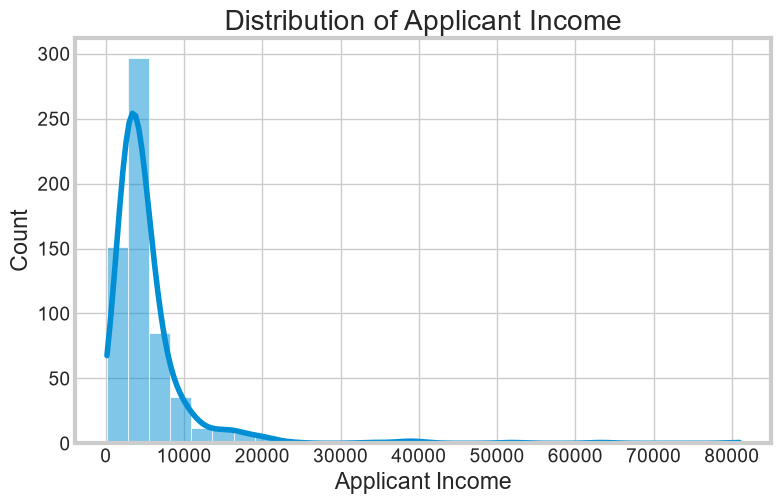

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data['ApplicantIncome'], kde=True, bins=30)
plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Count")
plt.show()

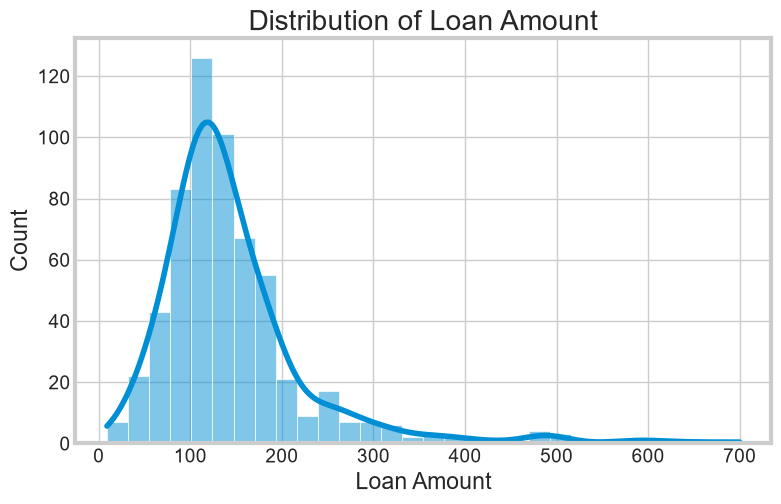

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data['LoanAmount'], kde=True, bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

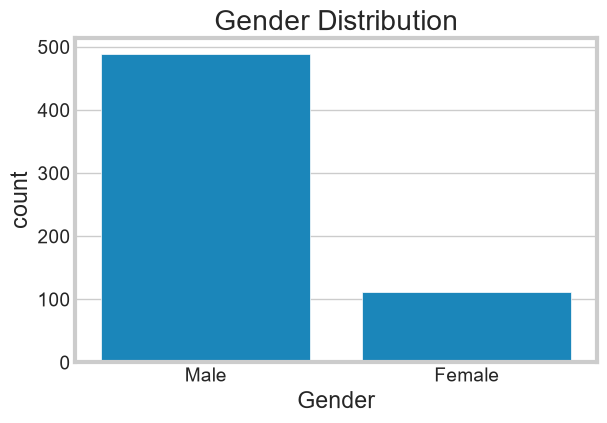

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=data)
plt.title("Gender Distribution")
plt.show()

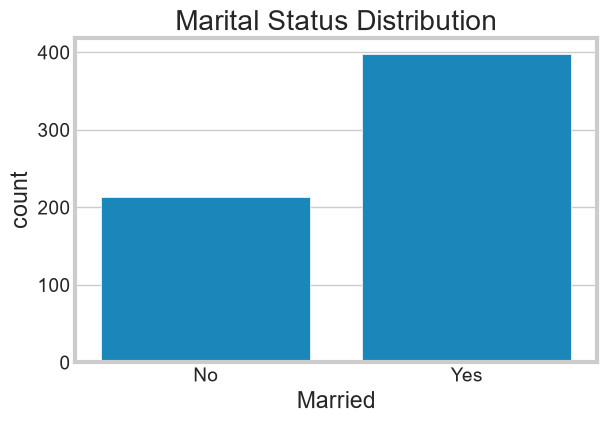

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Married', data=data)
plt.title("Marital Status Distribution")
plt.show()

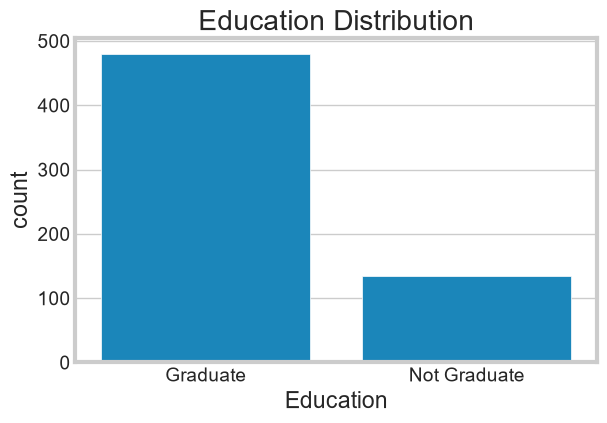

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', data=data)
plt.title("Education Distribution")
plt.show()

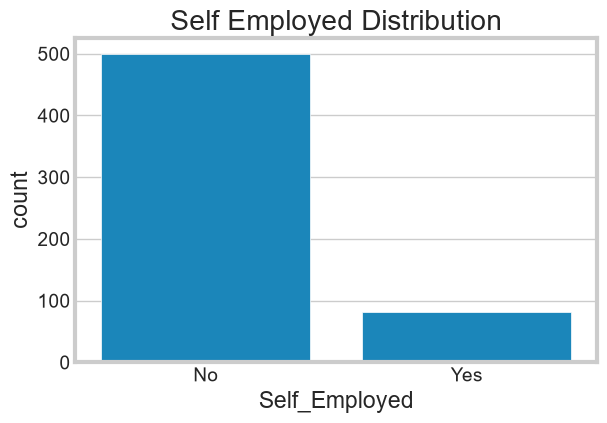

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='Self_Employed', data=data)
plt.title("Self Employed Distribution")
plt.show()

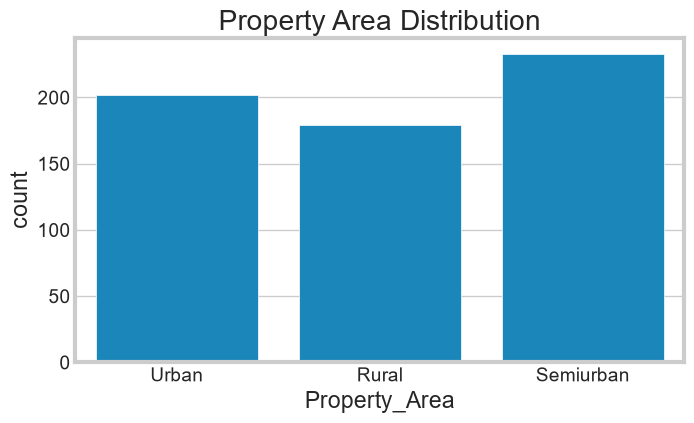

In [18]:
plt.figure(figsize=(7,4))
sns.countplot(x='Property_Area', data=data)
plt.title("Property Area Distribution")
plt.show()

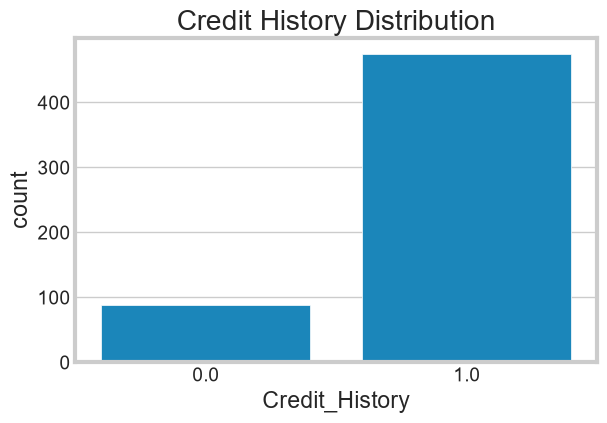

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', data=data)
plt.title("Credit History Distribution")
plt.show()

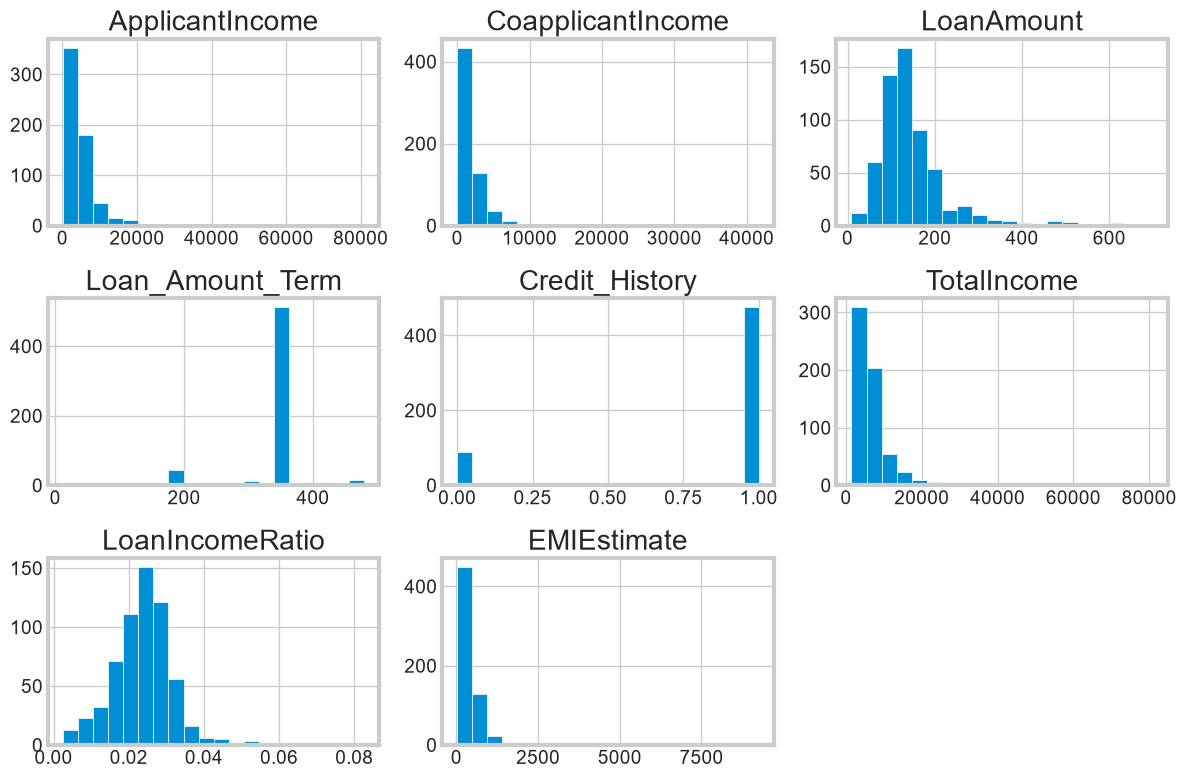

In [20]:
data[numerical_features].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

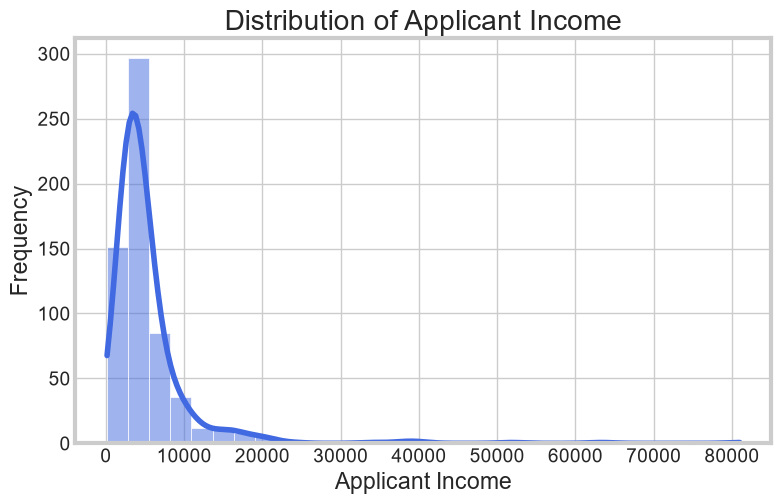

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(data["ApplicantIncome"], kde=True, bins=30, color="royalblue")

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

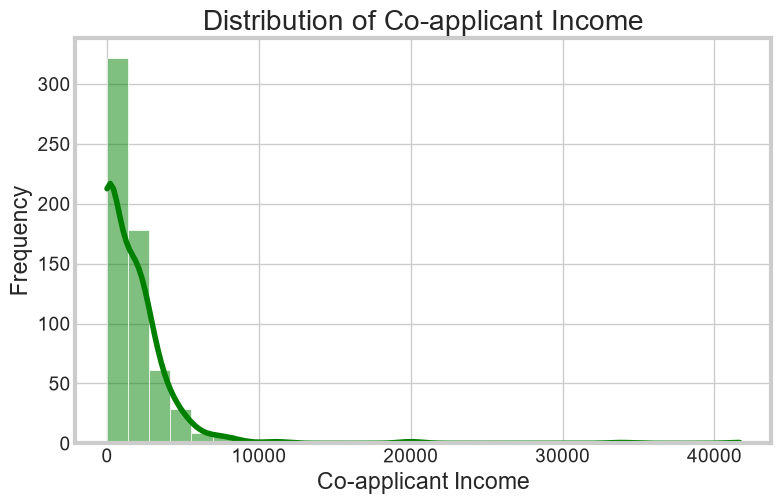

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(data["CoapplicantIncome"], kde=True, bins=30, color="green")

plt.title("Distribution of Co-applicant Income")
plt.xlabel("Co-applicant Income")
plt.ylabel("Frequency")

plt.show()

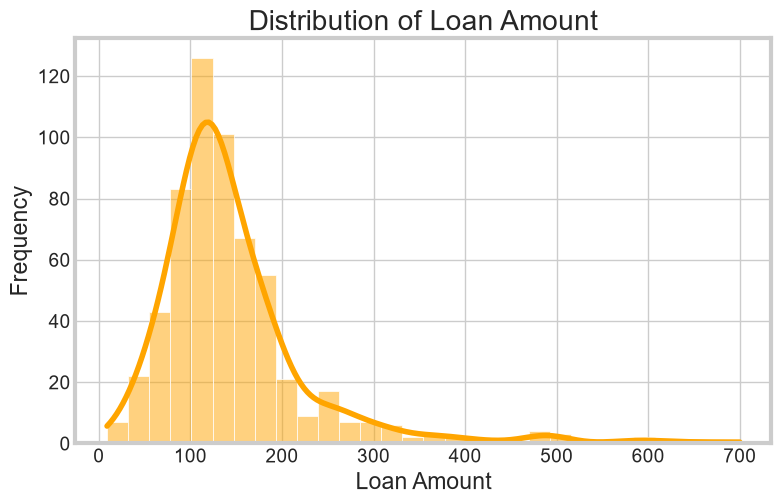

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(data["LoanAmount"], kde=True, bins=30, color="orange")

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

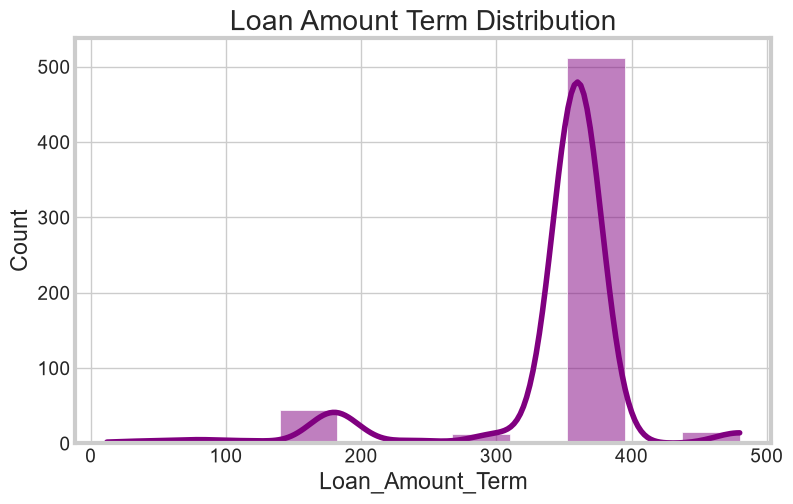

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(data["Loan_Amount_Term"], kde=True, color="purple")

plt.title("Loan Amount Term Distribution")

plt.show()

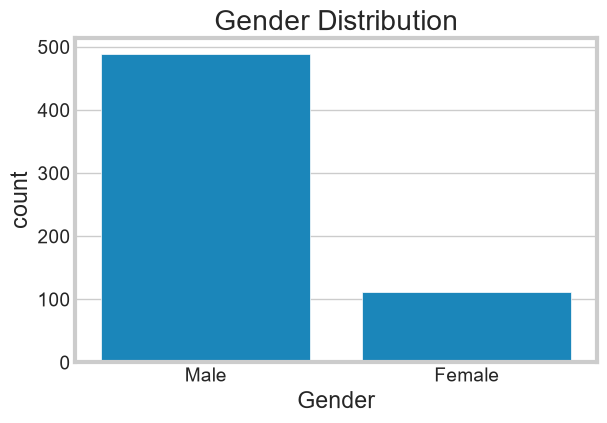

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=data)

plt.title("Gender Distribution")

plt.show()

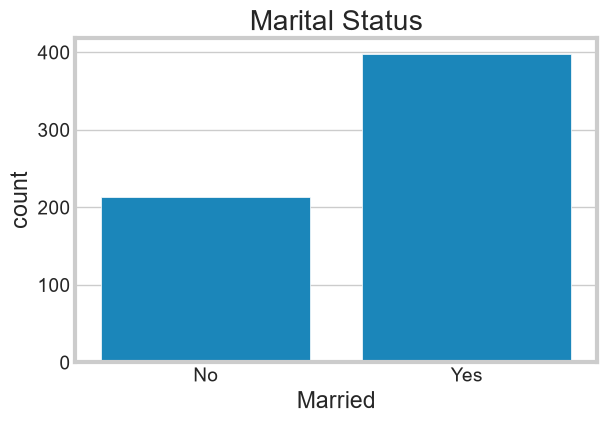

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x="Married", data=data)

plt.title("Marital Status")

plt.show()

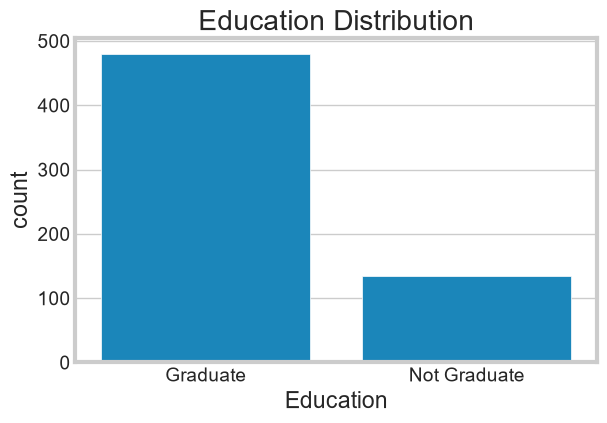

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x="Education", data=data)

plt.title("Education Distribution")

plt.show()

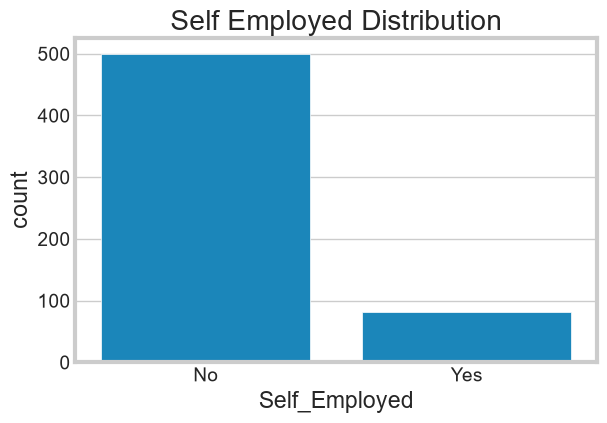

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x="Self_Employed", data=data)

plt.title("Self Employed Distribution")

plt.show()

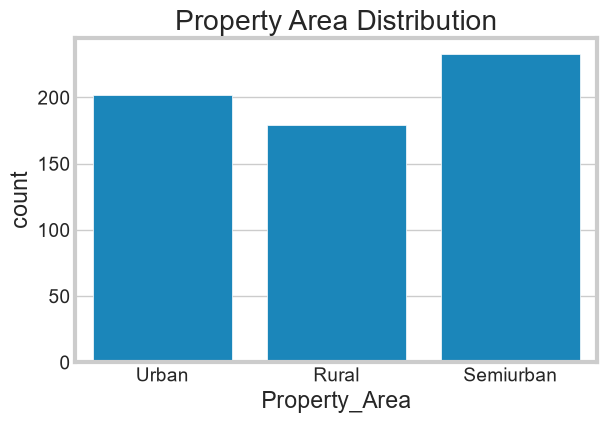

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x="Property_Area", data=data)

plt.title("Property Area Distribution")

plt.show()

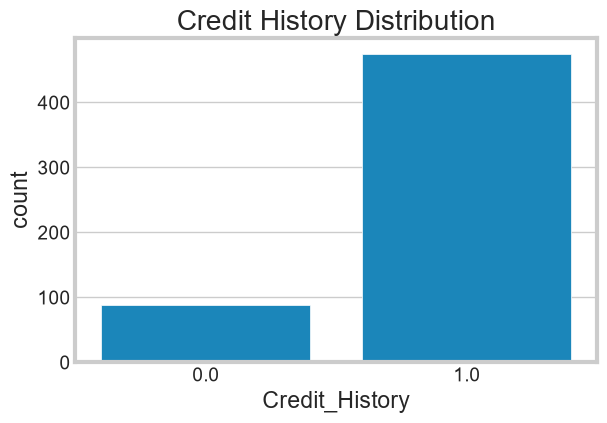

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x="Credit_History", data=data)

plt.title("Credit History Distribution")

plt.show()

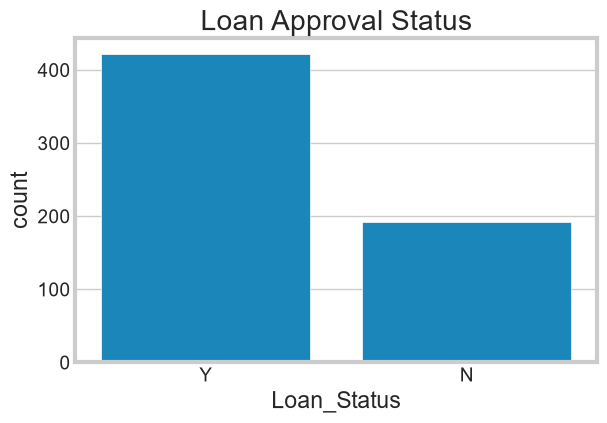

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x="Loan_Status", data=data)

plt.title("Loan Approval Status")

plt.show()

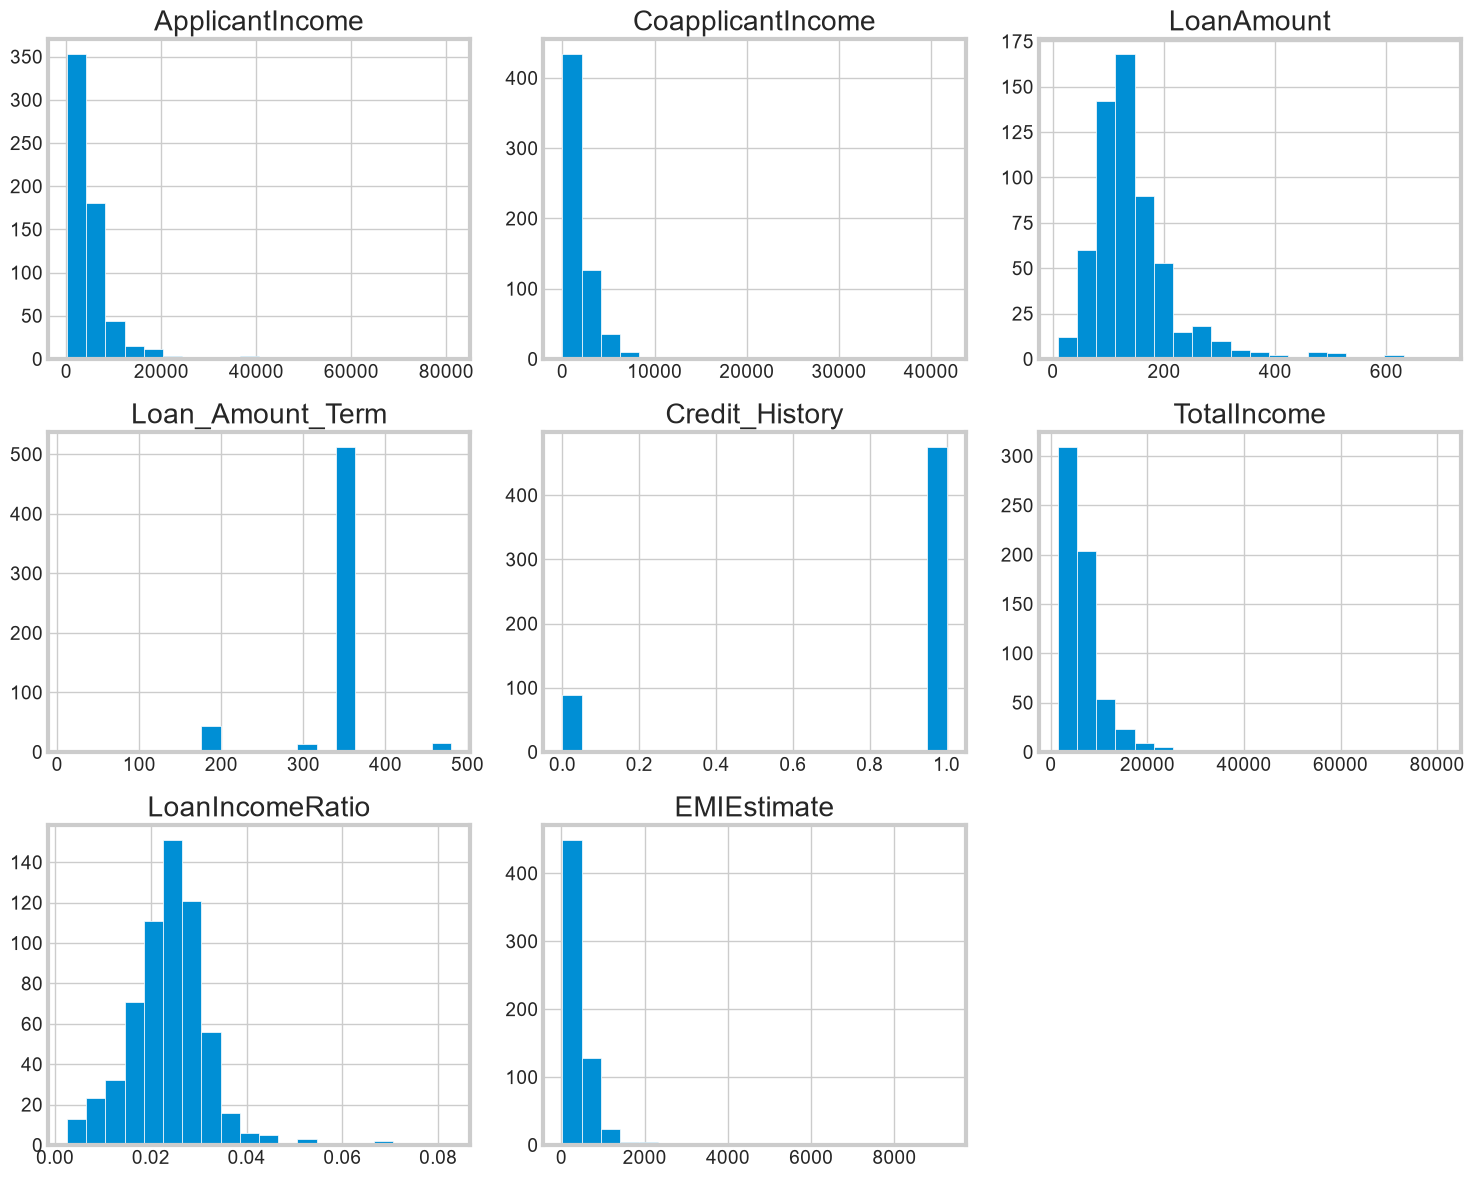

In [32]:
data.hist(figsize=(15,12), bins=20)

plt.tight_layout()

plt.show()

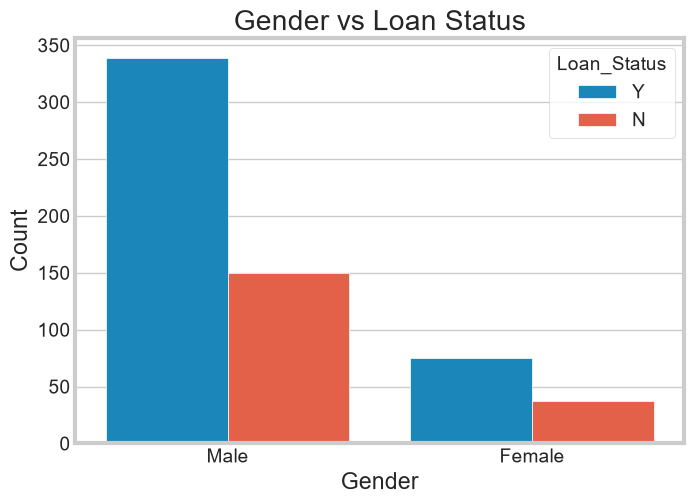

In [33]:
plt.figure(figsize=(7,5))
sns.countplot(x="Gender", hue="Loan_Status", data=data)

plt.title("Gender vs Loan Status")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

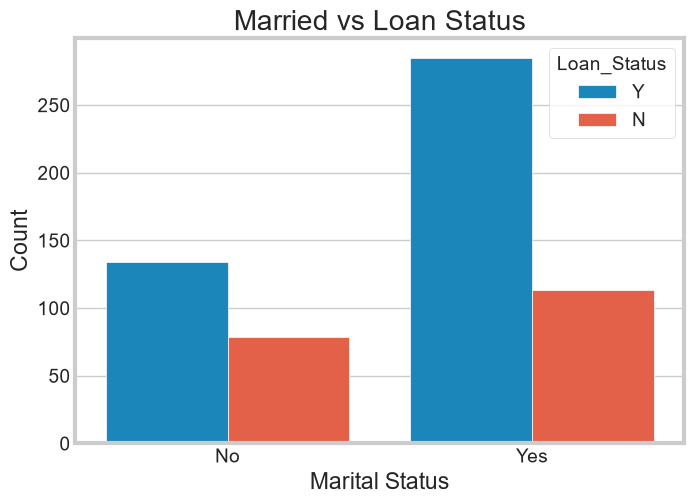

In [34]:
plt.figure(figsize=(7,5))
sns.countplot(x="Married", hue="Loan_Status", data=data)

plt.title("Married vs Loan Status")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.show()

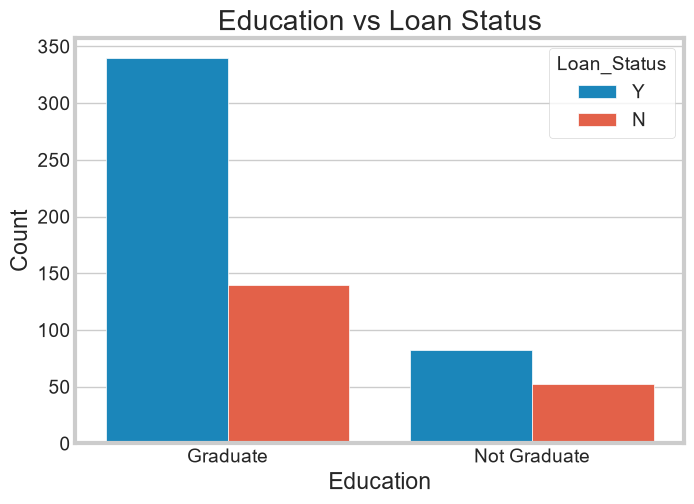

In [35]:
plt.figure(figsize=(7,5))
sns.countplot(x="Education", hue="Loan_Status", data=data)

plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Count")

plt.show()

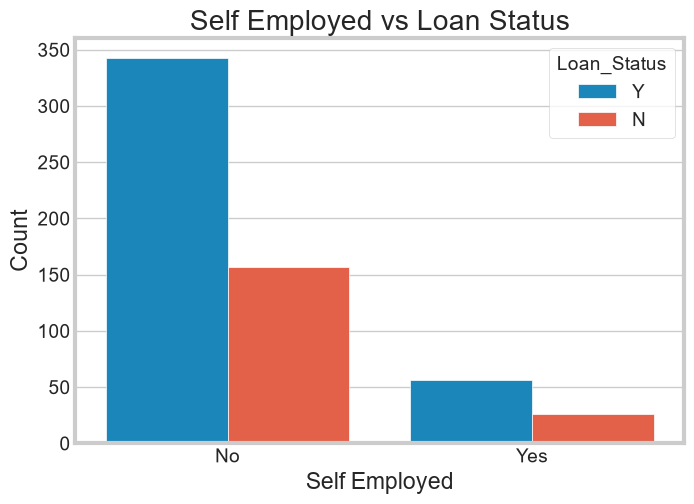

In [36]:
plt.figure(figsize=(7,5))
sns.countplot(x="Self_Employed", hue="Loan_Status", data=data)

plt.title("Self Employed vs Loan Status")
plt.xlabel("Self Employed")
plt.ylabel("Count")

plt.show()

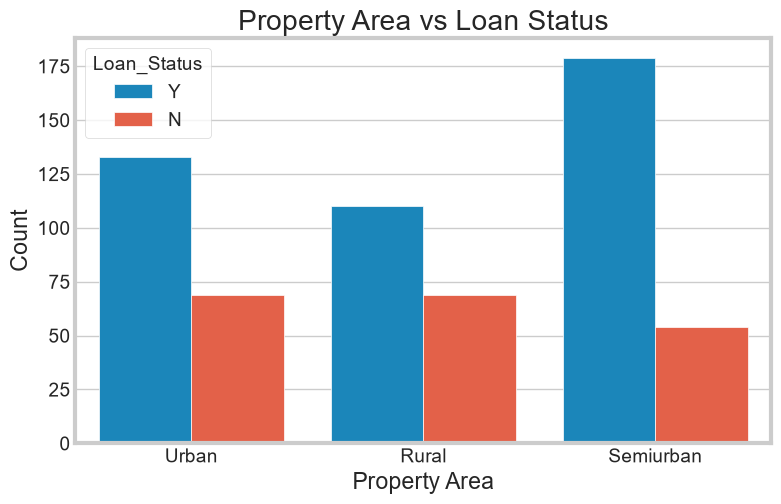

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(x="Property_Area", hue="Loan_Status", data=data)

plt.title("Property Area vs Loan Status")
plt.xlabel("Property Area")
plt.ylabel("Count")

plt.show()

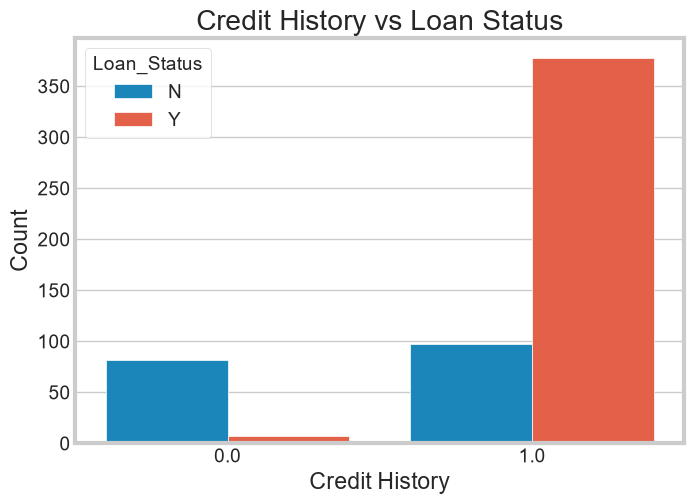

In [38]:
plt.figure(figsize=(7,5))
sns.countplot(x="Credit_History", hue="Loan_Status", data=data)

plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Count")

plt.show()

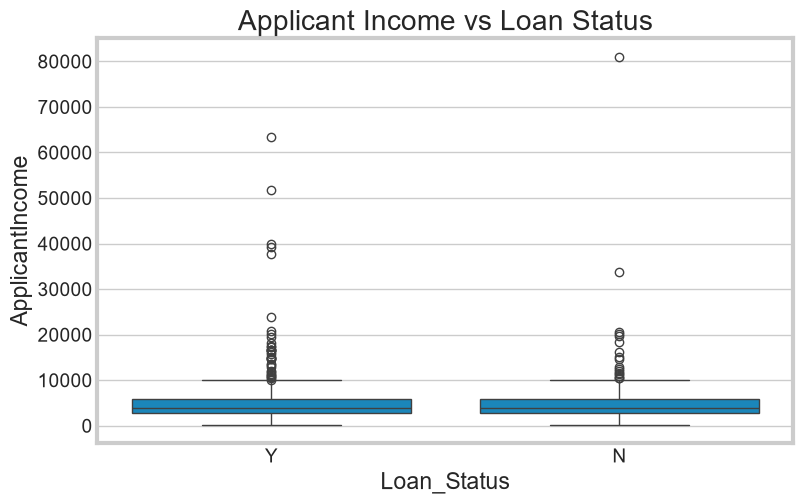

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Loan_Status",
            y="ApplicantIncome",
            data=data)

plt.title("Applicant Income vs Loan Status")

plt.show()

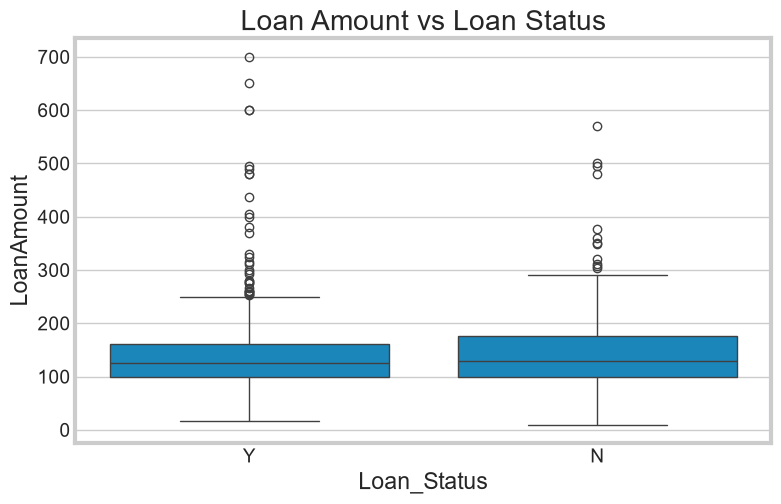

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Loan_Status",
            y="LoanAmount",
            data=data)

plt.title("Loan Amount vs Loan Status")

plt.show()

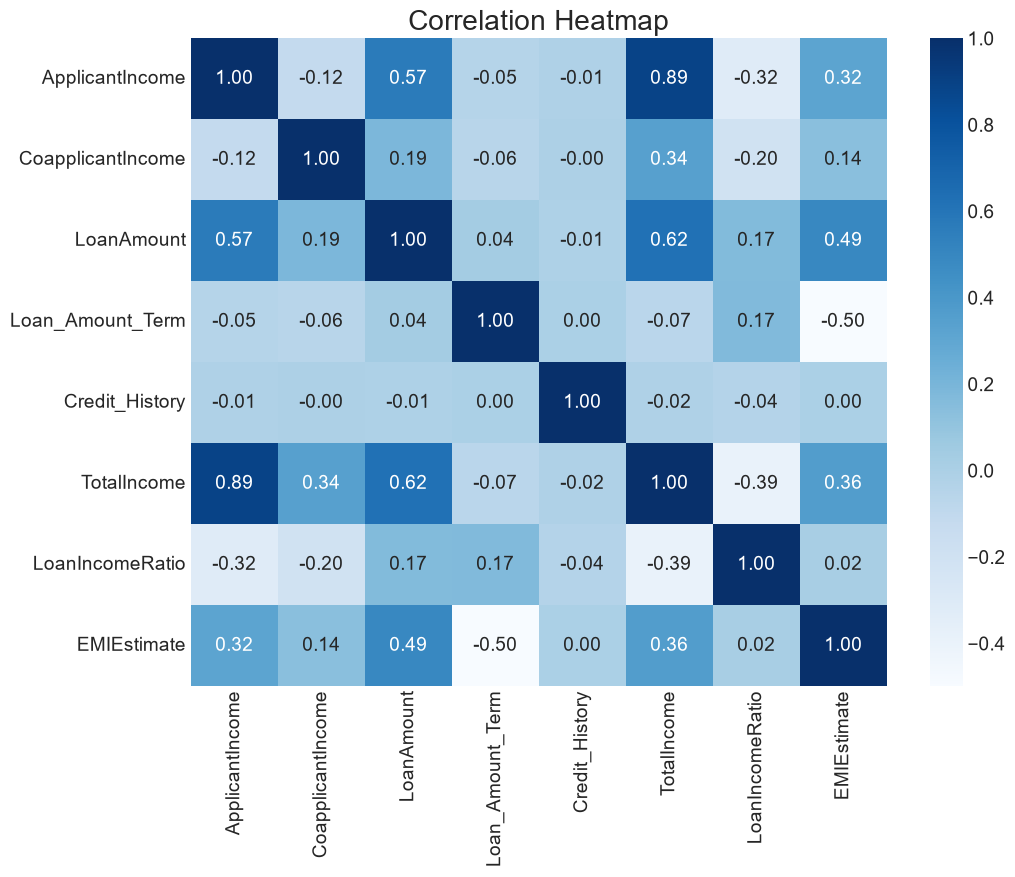

In [41]:
# Select only numerical columns
numeric_data = data.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

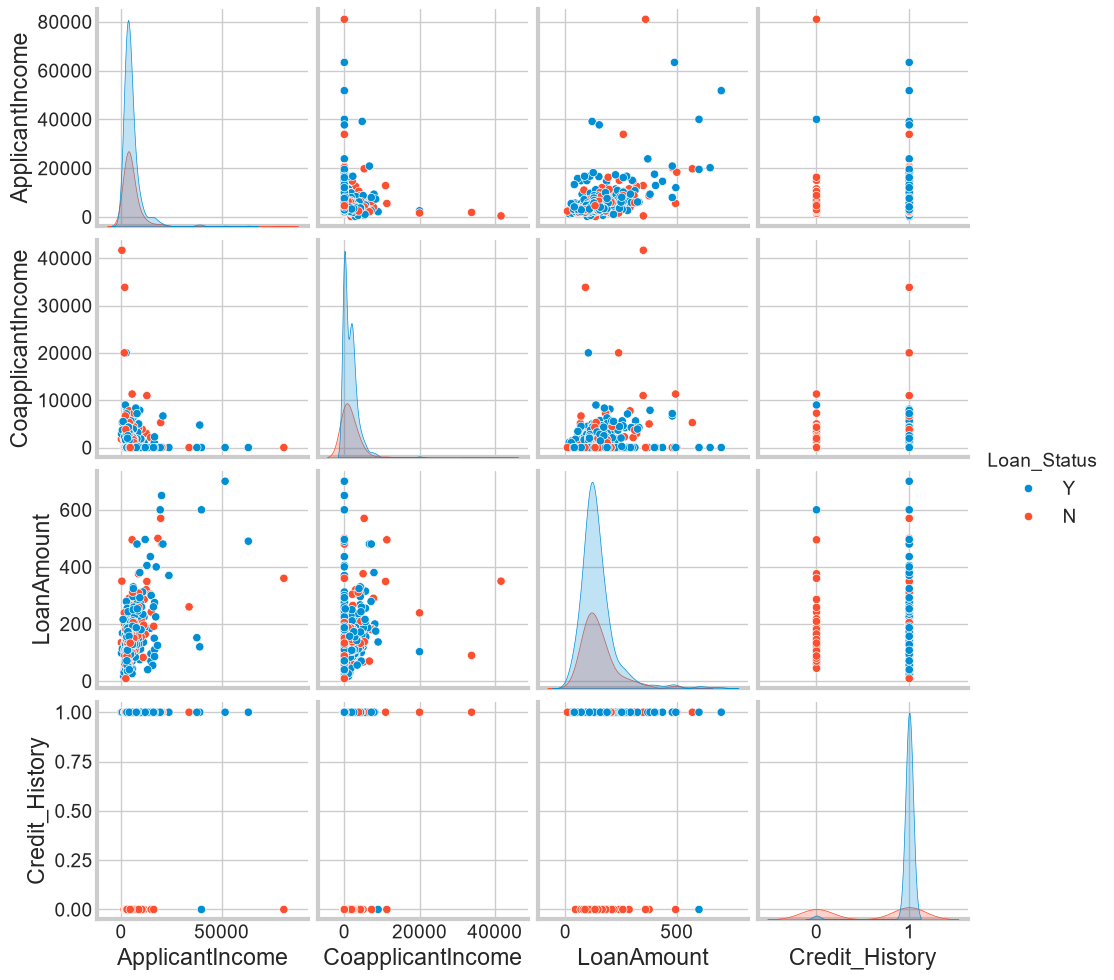

In [42]:
sns.pairplot(
    data[
        [
            "ApplicantIncome",
            "CoapplicantIncome",
            "LoanAmount",
            "Credit_History",
            "Loan_Status"
        ]
    ],
    hue="Loan_Status"
)

plt.show()

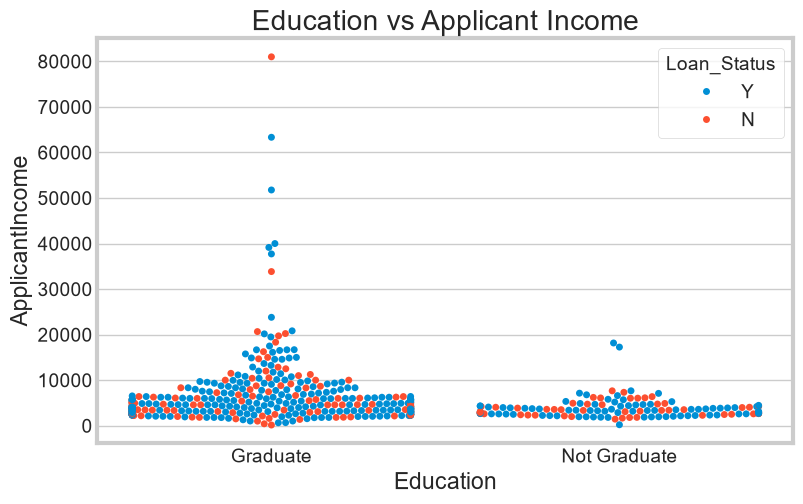

In [43]:
plt.figure(figsize=(8,5))

sns.swarmplot(
    x="Education",
    y="ApplicantIncome",
    hue="Loan_Status",
    data=data
)

plt.title("Education vs Applicant Income")

plt.show()

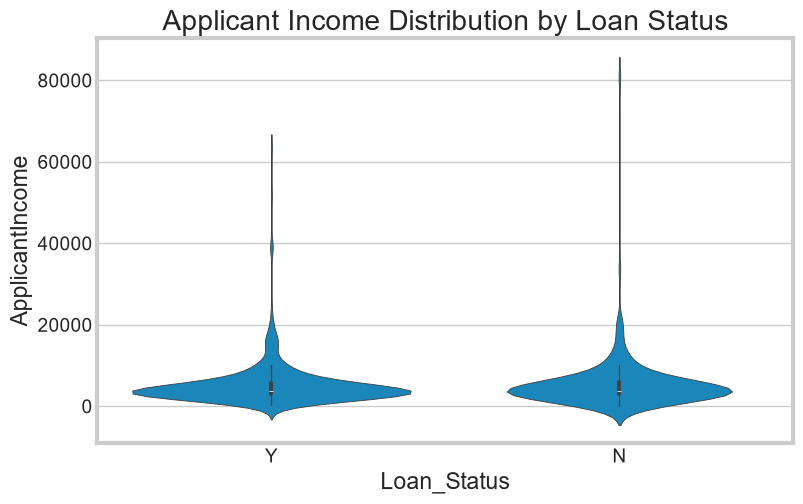

In [44]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x="Loan_Status",
    y="ApplicantIncome",
    data=data
)

plt.title("Applicant Income Distribution by Loan Status")

plt.show()

In [45]:
# Check Missing Values

data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
LoanIncomeRatio       0
EMIEstimate           0
IncomeCategory        0
dtype: int64

In [46]:
# Fill Numerical Missing Values

data["LoanAmount"].fillna(data["LoanAmount"].mean(), inplace=True)

data["Loan_Amount_Term"].fillna(data["Loan_Amount_Term"].mean(), inplace=True)

data["Credit_History"].fillna(data["Credit_History"].mode()[0], inplace=True)

In [47]:
# Fill Categorical Missing Values

data["Gender"].fillna(data["Gender"].mode()[0], inplace=True)

data["Married"].fillna(data["Married"].mode()[0], inplace=True)

data["Dependents"].fillna(data["Dependents"].mode()[0], inplace=True)

data["Self_Employed"].fillna(data["Self_Employed"].mode()[0], inplace=True)

In [48]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
TotalIncome          0
LoanIncomeRatio      0
EMIEstimate          0
IncomeCategory       0
dtype: int64

In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [50]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_columns:
    data[col] = le.fit_transform(data[col])

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,EMIEstimate,IncomeCategory
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1,5849.0,0.0219,355.56,Medium
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0,6091.0,0.0210,355.56,Medium
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1,3000.0,0.0220,183.33,Low
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1,4941.0,0.0243,333.33,Medium
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1,6000.0,0.0235,391.67,Medium


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
 13  TotalIncome        614 non-null    float64
 14  LoanIncomeRatio    614 non-null    float64
 15  EMIEstimate        614 non-null    float64
 16  IncomeCategory     614 non

In [52]:
data["TotalIncome"] = data["ApplicantIncome"] + data["CoapplicantIncome"]

In [53]:
data["LoanIncomeRatio"] = data["LoanAmount"] / data["TotalIncome"]

In [54]:
data["EMIEstimate"] = (data["LoanAmount"] * 1000) / data["Loan_Amount_Term"]

In [55]:
import numpy as np

data["IncomeCategory"] = pd.cut(
    data["TotalIncome"],
    bins=[0, 3000, 6000, 9000, np.inf],
    labels=[0, 1, 2, 3],
    include_lowest=True
)

data["IncomeCategory"] = data["IncomeCategory"].astype(int)

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,EMIEstimate,IncomeCategory
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1,5849.0,0.025032,406.700450,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0,6091.0,0.021015,355.555556,2
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1,3000.0,0.022000,183.333333,0
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1,4941.0,0.024287,333.333333,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1,6000.0,0.023500,391.666667,1


In [56]:
data["IncomeCategory"].isnull().sum()

np.int64(0)

In [57]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,EMIEstimate,IncomeCategory
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1,5849.0,0.025032,406.700450,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0,6091.0,0.021015,355.555556,2
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1,3000.0,0.022000,183.333333,0
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1,4941.0,0.024287,333.333333,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1,6000.0,0.023500,391.666667,1


In [62]:
# ==========================================
# Separate Features and Target Variable
# ==========================================

X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (614, 16)
Target Shape: (614,)


In [64]:
# Remove Loan_ID column
data = data.drop("Loan_ID", axis=1)

# Check remaining columns
data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome', 'LoanIncomeRatio', 'EMIEstimate', 'IncomeCategory'],
      dtype='object')

In [65]:
# Features and Target

X = data.drop("Loan_Status", axis=1)

y = data["Loan_Status"]

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LoanIncomeRatio,EMIEstimate,IncomeCategory
0,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,0.072991,-0.554487,0.000000,0.279851,0.411733,1.223298,-0.182184,0.113574,-0.135961,-0.577354
1,0.472343,0.728816,0.253470,-0.528362,-0.392601,-0.134412,-0.038732,-0.219273,0.279851,0.411733,-1.318513,-0.144684,-0.335797,-0.236137,0.573605
2,0.472343,0.728816,-0.737806,-0.528362,2.547117,-0.393747,-0.554487,-0.957641,0.279851,0.411733,1.223298,-0.623656,-0.225575,-0.573465,-1.728314
3,0.472343,0.728816,-0.737806,1.892641,-0.392601,-0.462062,0.251980,-0.314547,0.279851,0.411733,1.223298,-0.322885,0.030194,-0.279664,-0.577354
4,0.472343,-1.372089,-0.737806,-0.528362,-0.392601,0.097728,-0.554487,-0.064454,0.279851,0.411733,1.223298,-0.158785,-0.057790,-0.165407,-0.577354


In [67]:
# ==========================================
# Split Dataset
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)


Training Data : (491, 15)
Testing Data : (123, 15)


In [68]:
# ==========================================
# Decision Tree Model
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy : 0.7235772357723578

Confusion Matrix

[[26 17]
 [17 63]]

Classification Report

              precision    recall  f1-score   support

           0       0.60      0.60      0.60        43
           1       0.79      0.79      0.79        80

    accuracy                           0.72       123
   macro avg       0.70      0.70      0.70       123
weighted avg       0.72      0.72      0.72       123



In [69]:
# ==========================================
# Random Forest Model
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy : 0.7804878048780488

Confusion Matrix

[[22 21]
 [ 6 74]]

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.51      0.62        43
           1       0.78      0.93      0.85        80

    accuracy                           0.78       123
   macro avg       0.78      0.72      0.73       123
weighted avg       0.78      0.78      0.77       123



In [70]:
# ==========================================
# KNN Model
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy :", accuracy_score(y_test, knn_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report\n")
print(classification_report(y_test, knn_pred))

KNN Accuracy : 0.7723577235772358

Confusion Matrix

[[17 26]
 [ 2 78]]

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.40      0.55        43
           1       0.75      0.97      0.85        80

    accuracy                           0.77       123
   macro avg       0.82      0.69      0.70       123
weighted avg       0.80      0.77      0.74       123



In [71]:
# ==========================================
# Gradient Boosting Model
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy :", accuracy_score(y_test, gb_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, gb_pred))

print("\nClassification Report\n")
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy : 0.8048780487804879

Confusion Matrix

[[23 20]
 [ 4 76]]

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.53      0.66        43
           1       0.79      0.95      0.86        80

    accuracy                           0.80       123
   macro avg       0.82      0.74      0.76       123
weighted avg       0.81      0.80      0.79       123



In [72]:
# ==========================================
# Compare Model Accuracy
# ==========================================

model_names = [
    "Decision Tree",
    "Random Forest",
    "KNN",
    "Gradient Boosting"
]

accuracy_scores = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, gb_pred)
]

comparison = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_scores
})

comparison

,Model,Accuracy
0,Decision Tree,0.723577
1,Random Forest,0.780488
2,KNN,0.772358
3,Gradient Boosting,0.804878


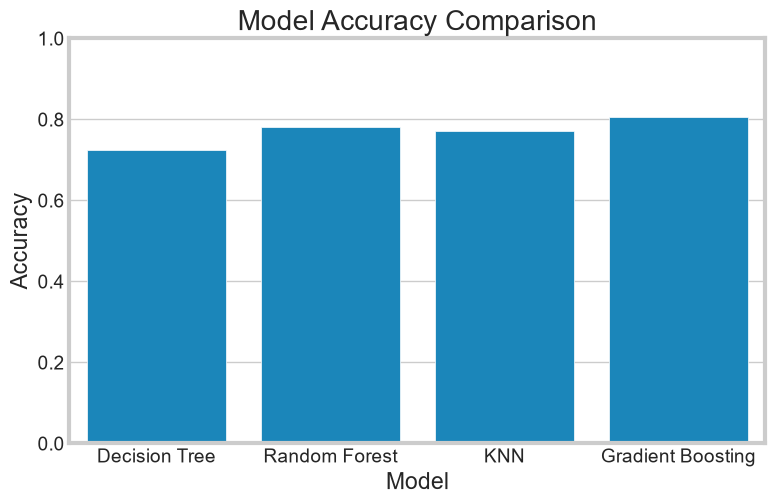

In [73]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

plt.show()

In [74]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print(best_model)

Model       Gradient Boosting
Accuracy             0.804878
Name: 3, dtype: object


In [75]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=5
)

print("Cross Validation Scores")

print(cv_scores)

print("\nAverage Accuracy :", cv_scores.mean())

Cross Validation Scores
[0.7804878  0.76422764 0.80487805 0.83739837 0.79508197]

Average Accuracy : 0.7964147674263627


In [76]:
import os
import pickle

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save Random Forest model
pickle.dump(
    rf,
    open("models/loan_model.pkl", "wb")
)

print("Model saved successfully.")

Model saved successfully.


In [77]:
loaded_model = pickle.load(
    open("models/loan_model.pkl", "rb")
)

print(loaded_model)

RandomForestClassifier(n_estimators=200, random_state=42)


In [78]:
sample = X_test.iloc[:5]

prediction = loaded_model.predict(sample)

print("Predictions :", prediction)

print("Actual Values :", y_test.iloc[:5].values)

Predictions : [1 1 1 1 1]
Actual Values : [1 1 1 1 1]


In [80]:


print(X.columns.tolist())

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome', 'LoanIncomeRatio', 'EMIEstimate', 'IncomeCategory']
